# circscale: full sweep on Colab GPU

Runs the whole scaling-law experiment: LR tuning, then the main sweep over a
Kaplan-style grid (width and depth co-scaled, constant-LR schedule, every
eval checkpoint an (N, D) datapoint). Roughly 30–60 min on a T4; the small
models are dispatch-bound, the big ones are where the GPU pays off.

**Setup**: Runtime → Change runtime type → GPU. Every stage is idempotent —
completed runs are skipped and interrupted runs resume from their checkpoint
(≤2500 steps lost), so disconnects are cheap, and with `USE_DRIVE = True`
below, `runs/` lives in your Google Drive and survives the runtime entirely.

In [1]:
# GPU + deps (Colab ships JAX; make sure it's the CUDA build)
!nvidia-smi -L
%pip -q install -U "jax[cuda12]" optax
import jax
print("jax", jax.__version__, jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend — enable a GPU runtime and restart")

GPU 0: Tesla T4 (UUID: GPU-658c16b3-abc0-b703-b73f-36d115722526)
jax 0.11.1 [CudaDevice(id=0)]


In [2]:
import os

REPO_URL = "https://github.com/amdson/circscale.git"

if not os.path.exists("/content/circscale"):
    !git clone $REPO_URL /content/circscale
%cd /content/circscale
!git pull

Cloning into '/content/circscale'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 53 (delta 26), reused 42 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 119.38 KiB | 10.85 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/circscale
Already up to date.


In [3]:
# Persist runs/ to Drive so nothing is lost when the runtime dies.
USE_DRIVE = True

import os
if USE_DRIVE and not os.path.islink("runs"):
    from google.colab import drive
    drive.mount("/content/drive")
    target = "/content/drive/MyDrive/circscale_runs"
    os.makedirs(target, exist_ok=True)
    assert not os.path.exists("runs"), "runs/ already exists as a plain dir"
    os.symlink(target, "runs")
print("runs ->", os.path.realpath("runs"))

Mounted at /content/drive
runs -> /content/drive/MyDrive/circscale_runs


In [4]:
# Optional ~1 min sanity check of circuit + model on this backend.
!python -m pytest -q -x test_random_circuit.py test_mlp.py

..
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! KeyboardInterrupt !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
/usr/local/lib/python3.13/dist-packages/jax/_src/dispatch.py:196: KeyboardInterrupt
(to show a full traceback on KeyboardInterrupt use --full-trace)
2 passed in 3.58s


## Sweep configuration

The scale grid is (width, MLP depth) pairs with depth ~ sqrt(width), per
Kaplan (scale N by growing both; rely on shape-insensitivity for the exact
aspect ratio), at half-octave width spacing with one seed per shape — noise
is absorbed by fitting across the finer grid rather than by replicates. Edit
here — stages read these at call time, and already-done runs are keyed by
shape, so changing the grid only adds work.

In [5]:
import sweep

sweep.GRID = [(32, 2), (48, 2), (64, 3), (96, 3), (128, 4),
              (180, 5), (256, 6), (360, 7), (512, 8)]
sweep.SEEDS = {}  # width -> seed list; default [0] (add replicates here later)
# Also configurable: sweep.LR_GRID, sweep.TUNE_STEPS, sweep.FULL_STEPS, sweep.BATCH

for w, d in sweep.GRID:
    print(f"w{w:<4} d{d:<3} trunk params ~ {8 * d * w * w / 1e6:7.3f}M  "
          f"seeds {sweep.SEEDS.get(w, [0])}")

w32   d2   trunk params ~   0.016M  seeds [0]
w48   d2   trunk params ~   0.037M  seeds [0]
w64   d3   trunk params ~   0.098M  seeds [0]
w96   d3   trunk params ~   0.221M  seeds [0]
w128  d4   trunk params ~   0.524M  seeds [0]
w180  d5   trunk params ~   1.296M  seeds [0]
w256  d6   trunk params ~   3.146M  seeds [0]
w360  d7   trunk params ~   7.258M  seeds [0]
w512  d8   trunk params ~  16.777M  seeds [0]


## Stage 1: LR tuning

5k-step runs over LRs {1e-4, 3e-4, 1e-3, 3e-3, 1e-2} per shape; writes
`runs/lr_table.json` and warns if any best LR sits on the grid edge (extend
`LR_GRID` in `sweep.py` and re-run this cell before trusting the sweep).

In [ ]:
from sweep import stage_lr_tune

stage_lr_tune()

## Stage 2: main sweep

Full 50k-step runs over the grid at tuned LRs, seeds per shape.
Interrupt any time; re-running the cell resumes.

In [ ]:
from sweep import stage_main

stage_main()

In [ ]:
sweep.stage_status()

## Quick look

Sanity plots straight off the run files (the real fitting — envelope,
L(N, D) joint fit, bootstrap CIs — belongs in a separate analysis notebook).

In [10]:
for run in runs:
  print(n_params(run[0]))

590464
1389240
3278592
32864
49312
49312
49312
7444800
61584
17043968
131328
164160
39566100
270720


14 runs


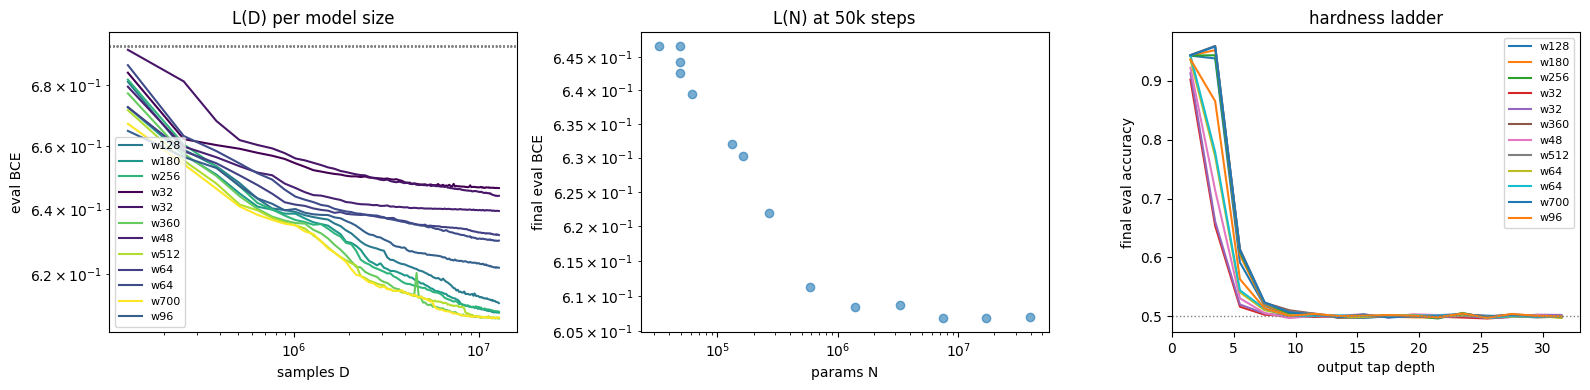

In [12]:
import glob

import matplotlib.pyplot as plt
import numpy as np

from train import load_run

runs = [load_run(p) for p in sorted(glob.glob("runs/*.npz"))]
print(f"{len(runs)} runs")


def n_params(c):
    w, d, r = c["width"], c["mlp_depth"], c["hidden_ratio"]
    return c["n_wires"] * 2 * w + d * (2 * r * w * w + w) + w

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

param_counts = [n_params(c) for c, _ in runs]
import matplotlib as mpl
cmap = mpl.colormaps['viridis']
norm = mpl.colors.LogNorm(vmin=min(param_counts), vmax=max(param_counts))

# eval loss vs samples consumed, one curve per width (seed 0)
for c, d in runs:
    if c["model_seed"] != 0:
        continue
    D = d["eval_steps"][1:] * c["batch"]
    axes[0].plot(D, d["per_out_loss"][1:].mean(axis=1), label=f"w{c['width']}", c=cmap(norm(n_params(c))))
    axes[0].axhline(np.log(2), color="gray", ls=":", lw=1)
axes[0].set(xscale="log", yscale="log", xlabel="samples D", ylabel="eval BCE")
axes[0].axhline(np.log(2), color="gray", ls=":", lw=1)
axes[0].legend(fontsize=8); axes[0].set_title("L(D) per model size")

# final loss vs params, all seeds
for c, d in runs:
    axes[1].plot(n_params(c), d["per_out_loss"][-1].mean(), "o", color="tab:blue", alpha=0.6)
axes[1].set(xscale="log", yscale="log", xlabel="params N", ylabel="final eval BCE")
axes[1].set_title("L(N) at 50k steps")

# final accuracy vs output tap depth, per width (seed 0)
for c, d in runs:
    if c["model_seed"] != 0:
        continue
    depths, acc = d["out_depths"], d["per_out_acc"][-1]
    bins = np.arange(1, depths.max() + 2, 2)
    mids, means = [], []
    for lo in bins[:-1]:
        sel = (depths >= lo) & (depths < lo + 2)
        if sel.any():
            mids.append(lo + 0.5); means.append(acc[sel].mean())
    axes[2].plot(mids, means, label=f"w{c['width']}")
axes[2].axhline(0.5, color="gray", ls=":", lw=1)
axes[2].set(xlabel="output tap depth", ylabel="final eval accuracy")
axes[2].legend(fontsize=8); axes[2].set_title("hardness ladder")
plt.tight_layout()

## AdamW comparison arm (cheap)

Reruns a subset of shapes with AdamW — decoupled weight decay, which the
grokking literature ties to earlier/sharper delayed transitions, worth a
control given the per-output staircase dynamics. This is a **separate
labeled condition** (`_adamwwd*` in run names), never mixed into the main
fit. Budgets are truncated using the completed Adam runs: each shape trains
only as long as its Adam counterpart took to first come within `TRUNC_TOL`
of its own final loss. Adam-tuned LRs are reused — if AdamW wins by a lot,
retune before trusting exact numbers.

In [17]:
import json
from dataclasses import replace

import numpy as np

from train import load_run, run

ADAMW_SHAPES = [(48, 2), (128, 4), (360, 7)]
WEIGHT_DECAY = 1e-2
TRUNC_TOL = 1.01

lr_table = json.loads(open("runs/lr_table.json").read())
adamw_cfgs = []
for w, dpt in ADAMW_SHAPES:
    base = sweep.main_cfg(w, dpt, lr_table[f"w{w}d{dpt}"], 0)
    _, r = load_run(base.npz_path)  # requires the Adam run to be done
    L = r["per_out_loss"].mean(axis=1)
    cut = int(r["eval_steps"][np.argmax(L <= L[-1] * TRUNC_TOL)])
    steps = max(cut, 5000)
    adamw_cfgs.append(replace(base, steps=steps, optimizer="adamw",
                              weight_decay=WEIGHT_DECAY))
    print(f"w{w}d{dpt}: adam within {TRUNC_TOL}x of final at step {cut:,} "
          f"-> adamw budget {steps:,} (vs {base.steps:,})")

TypeError: RunConfig.__init__() got an unexpected keyword argument 'optimizer'

In [ ]:
for cfg in adamw_cfgs:
    run(cfg)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(adamw_cfgs), figsize=(4.5 * len(adamw_cfgs), 3.8),
                         sharey=True)
for ax, cfg in zip(np.atleast_1d(axes), adamw_cfgs):
    base = replace(cfg, steps=sweep.FULL_STEPS, optimizer="adam", weight_decay=0.0)
    _, r = load_run(base.npz_path)
    sel = r["eval_steps"] >= 1000
    ax.plot(r["eval_steps"][sel] * base.batch, r["per_out_loss"][sel].mean(axis=1),
            label="adam")
    if cfg.npz_path.exists():
        _, ra = load_run(cfg.npz_path)
        sa = ra["eval_steps"] >= 1000
        ax.plot(ra["eval_steps"][sa] * cfg.batch, ra["per_out_loss"][sa].mean(axis=1),
                label=f"adamw wd={cfg.weight_decay:g}")
    ax.set(xscale="log", yscale="log", xlabel="samples D",
           title=f"w{cfg.width}d{cfg.mlp_depth}")
np.atleast_1d(axes)[0].set_ylabel("eval BCE")
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# If not using Drive: zip results and download before the runtime dies.
if not USE_DRIVE:
    !zip -qr circscale_runs.zip runs
    from google.colab import files
    files.download("circscale_runs.zip")